<a href="https://colab.research.google.com/github/aranzatorres546-hash/M-TODOS-NUM-RICOS-/blob/main/punto_fijo_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(90deg,#1f4e79,#2e86c1);padding:18px 22px;border-radius:10px;color:white">
<h1 style="margin:0;color:white">Método de Punto Fijo</h1>
<p style="margin:4px 0 0 0;font-size:16px">Solución numérica de $3x^2-e^x=0$ &nbsp;|&nbsp; Métodos Numéricos</p>
</div>

**Nombre:** Aranza Citlali Rivero Torres

---




Se desea encontrar una raíz real de la ecuación no lineal

$$f(x)=3x^2-e^x=0 .$$

Esta ecuación **no se puede despejar de forma analítica** (mezcla un polinomio con una exponencial), por lo que se resuelve de forma numérica con el **método de punto fijo**.

> **Objetivo:** encontrar $p$ tal que $f(p)=0$, comprobar que el método converge y presentar el resultado final de forma clara.


Se reescribe $f(x)=0$ en una forma equivalente

$$x=g(x),$$

de modo que una raíz de $f$ es un **punto fijo** de $g$, es decir, un valor $p$ con $g(p)=p$. A partir de una aproximación inicial $p_0$ se genera la sucesión

$$p_{n+1}=g(p_n),\qquad n=0,1,2,\dots$$

#Teorema de connvergencia
Si $g\in C[a,b]$ y se cumple que

1. $g(x)\in[a,b]$ para todo $x\in[a,b]$, y
2. existe una constante $0<k<1$ tal que $|g'(x)|\le k$ para todo $x\in(a,b)$,b

entonces $g$ tiene **un único** punto fijo $p\in[a,b]$ y la sucesión $p_n$ converge a $p$ para cualquier $p_0\in[a,b]$. Además se tiene la cota

$$|p_n-p|\le \frac{k^n}{1-k}\,|p_1-p_0| .$$


Por el criterio de Parada,la iteración se detiene cuando dos aproximaciones consecutivas están más cerca que la tolerancia:

$$|p_{n+1}-p_n|<\text{tol}\qquad\text{o cuando se alcanzan }n_{\max}\text{ iteraciones.}$$

Para el algoritmo:
1. Elegir $g$, $p_0$, `tol` y `nmax`.
2. Calcular $p_{n+1}=g(p_n)$ y el error $|p_{n+1}-p_n|$
3. Si el error es menor que `tol`, terminar con $p\approx p_{n+1}$. Si no, hacer $p_n\leftarrow p_{n+1}$ y repetir el paso 2.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

**Comentarios sobre la sintaxis:**
- `import ... as ...` carga una librería y le asigna un nombre corto (`np`, `plt`, `pd`).
- `numpy` aporta las funciones matemáticas (`np.exp`, `np.sqrt`, `np.linspace`) que trabajan con números y con arreglos completos.
- `matplotlib.pyplot` sirve para las gráficas y `pandas` para organizar los datos en una tabla (`DataFrame`).
- `from tabulate import tabulate` importa solo la función `tabulate`, que imprime tablas con formato.


Se programa $f(x)=3x^2-e^x$, la función cuya raíz se busca.

In [13]:
def f(x):
    return 3*x**2 - np.exp(x)

**Comentarios sobre la sintaxis:** `def` define una función; `x` es su parámetro y puede ser un número o un arreglo de NumPy. El operador `**` es la potencia (`x**2` es $x^2$) y `return` devuelve el resultado.


Antes de iterar conviene saber **dónde** está la raíz. Si $f$ cambia de signo en un intervalo, el teorema del valor intermedio garantiza que hay una raíz dentro de él.

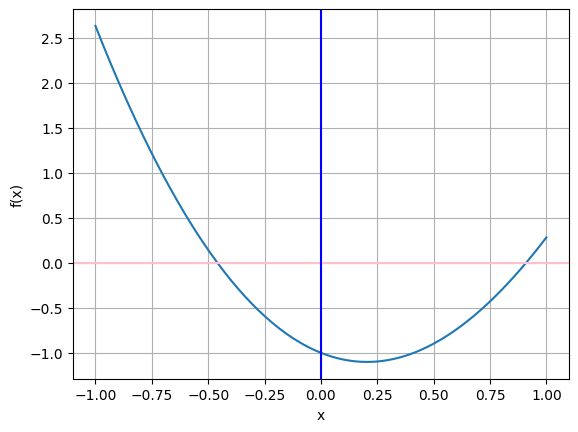

In [14]:
import numpy as np
import matplotlib.pyplot as plt

xx = np.linspace(-1, 1, 200)
plt.plot(xx, f(xx))
plt.axhline(y=0, color='pink')
plt.axvline(x=0, color='blue')
plt.grid(True)
plt.xlabel('x'); plt.ylabel('f(x)')
plt.show()

**Lectura de la gráfica:** en $[-1,1]$ la curva cruza el eje $x$ en **dos puntos**: uno cerca de $x\approx-0.46$ y otro cerca de $x\approx0.91$. Este último es el que se calcula con el método; el valor $p_0=0.9$ se elige por estar muy cerca de ese cruce. (La ecuación tiene además una tercera raíz cerca de $x\approx3.73$, fuera de la ventana graficada.)

**Comentarios sobre la sintaxis:** `np.linspace(-1, 1, 200)` crea 200 puntos igualmente espaciados entre $-1$ y $1$; `plt.plot` dibuja la curva; `plt.axhline` y `plt.axvline` trazan los ejes de color rosa y azul; `plt.grid(True)` activa la cuadrícula y `plt.xlabel`/`plt.ylabel` ponen las etiquetas. En una misma línea se pueden escribir dos instrucciones separándolas con `;`.

 Función de iteración $g(x):
 $
Despejando $x^2$ de $3x^2-e^x=0$ se obtiene

$$x^2=\frac{e^x}{3}\;\;\Longrightarrow\;\; \boxed{\,g(x)=\sqrt{\frac{e^x}{3}}\,}\qquad(\text{rama positiva}).$$

Su derivada es

$$g'(x)=\frac12\sqrt{\frac{e^x}{3}}=\frac{g(x)}{2}>0 .$$

**Verificación de las hipótesis del teorema en $[a,b]=[0.5,\,1]$:**

| Hipótesis | Cálculo | ¿Se cumple? |
|:---|:---|:---:|
| $g([a,b])\subset[a,b]$ | $g$ es creciente: $g(0.5)\approx0.7413$ y $g(1)\approx0.9519$, ambos dentro de $[0.5,1]$ | Sí |
| $\lvert g'(x)\rvert\le k<1$ | $g'$ es creciente, su máximo está en $x=1$: $k=g'(1)\approx0.476$ | Sí |

<div style="border-left:6px solid #27ae60;background:#eafaf1;padding:10px 14px;border-radius:4px">
<b>Conclusión:</b> se cumplen las dos hipótesis con $k\approx0.476<1$. Por el teorema, la iteración $p_{n+1}=\sqrt{e^{p_n}/3}$ converge al único punto fijo de $[0.5,1]$ para cualquier $p_0$ en ese intervalo.
</div>

In [15]:
def g(x):
    return np.sqrt(np.exp(x)/3)

**Comentarios sobre la sintaxis:** `np.sqrt` es la raíz cuadrada y `np.exp(x)` es $e^x$. Con los mismos nombres que en la teoría, `g(x)` devuelve $\sqrt{e^x/3}$.


La función `punto_fijo` aplica el algoritmo de la sección 2.4: repite $p_{n+1}=g(p_n)$, guarda cada iteración en una tabla y se detiene cuando $|p_{n+1}-p_n|<\text{tol}$ o cuando llega a `nmax` iteraciones.

In [17]:
def punto_fijo(g, p0, tol=1e-6, nmax=100):
    filas = []
    for n in range(1, nmax + 1):
        p1 = g(p0)
        error = abs(p1 - p0)
        filas.append([n, p0, p1, error])
        if error < tol:
            break
        p0 = p1
    tabla = pd.DataFrame(filas, columns=['n', 'p_n', 'p_n+1 = g(p_n)', 'error'])
    return p1, tabla

**Comentarios sobre la sintaxis:**
- `def punto_fijo(g, p0, tol=1e-6, nmax=100)`: la función recibe **otra función** (`g`) como argumento; `tol` y `nmax` tienen valores por defecto que se pueden cambiar al llamarla.
- `filas = []` crea una lista vacía y `filas.append([...])` le agrega una fila en cada vuelta del ciclo.
- `for n in range(1, nmax + 1)` repite el bloque con `n = 1, 2, ..., nmax`; la sangría (indentación) indica qué instrucciones pertenecen al ciclo.
- `abs(p1 - p0)` es el valor absoluto, es decir, el error entre dos iteraciones.
- `if error < tol: break` evalúa el criterio de paro y `break` sale del ciclo.
- `p0 = p1` actualiza la aproximación para la siguiente vuelta.
- `pd.DataFrame(filas, columns=[...])` convierte la lista de filas en una tabla con nombres de columna.
- `return p1, tabla` devuelve dos valores a la vez.


Se ejecuta el método con $p_0=0.9$, tolerancia $10^{-6}$ y un máximo de 50 iteraciones. La tabla muestra en cada fila el valor $p_n$, el siguiente valor $p_{n+1}=g(p_n)$ y el error $|p_{n+1}-p_n|$.

In [18]:
import pandas as pd
from tabulate import tabulate

raiz, tabla = punto_fijo(g, p0=0.9, tol=1e-6, nmax=50)

print(tabulate(tabla.itertuples(index=False), headers=tabla.columns, tablefmt='fancy_grid',
               floatfmt=('.0f', '.8f', '.8f', '.2e')))

╒═════╤════════════╤══════════════════╤══════════╕
│   n │        p_n │   p_n+1 = g(p_n) │    error │
╞═════╪════════════╪══════════════════╪══════════╡
│   1 │ 0.90000000 │       0.90546546 │ 5.47e-03 │
├─────┼────────────┼──────────────────┼──────────┤
│   2 │ 0.90546546 │       0.90794324 │ 2.48e-03 │
├─────┼────────────┼──────────────────┼──────────┤
│   3 │ 0.90794324 │       0.90906878 │ 1.13e-03 │
├─────┼────────────┼──────────────────┼──────────┤
│   4 │ 0.90906878 │       0.90958052 │ 5.12e-04 │
├─────┼────────────┼──────────────────┼──────────┤
│   5 │ 0.90958052 │       0.90981328 │ 2.33e-04 │
├─────┼────────────┼──────────────────┼──────────┤
│   6 │ 0.90981328 │       0.90991917 │ 1.06e-04 │
├─────┼────────────┼──────────────────┼──────────┤
│   7 │ 0.90991917 │       0.90996735 │ 4.82e-05 │
├─────┼────────────┼──────────────────┼──────────┤
│   8 │ 0.90996735 │       0.90998927 │ 2.19e-05 │
├─────┼────────────┼──────────────────┼──────────┤
│   9 │ 0.90998927 │       0.90

**Cómo leer la tabla:** el error disminuye en cada fila (de $5.47\times10^{-3}$ a $9.40\times10^{-7}$) y los valores de $p_{n+1}$ se estabilizan en $0.910006\ldots$. La iteración se detuvo en la fila 12 porque ahí el error ya es menor que $10^{-6}$.

**Comentarios sobre la sintaxis:** `raiz, tabla = punto_fijo(...)` desempaqueta los dos valores devueltos. `tabulate(...)` imprime la tabla: `tabla.itertuples(index=False)` entrega las filas sin el índice, `headers=tabla.columns` pone los títulos, `tablefmt='fancy_grid'` define el estilo con bordes y `floatfmt` da el formato de cada columna (entero, 8 decimales, 8 decimales y notación científica `.2e`).

In [19]:
print(f'Raíz aproximada: {raiz:.8f}')
print(f'f(raíz) = {f(raiz):.2e}')
print(f'Iteraciones: {len(tabla)}')

Raíz aproximada: 0.91000679
f(raíz) = -2.33e-06
Iteraciones: 12


**Comentarios sobre la sintaxis:** las cadenas que empiezan con `f'...'` (*f-strings*) insertan el valor de una variable dentro de las llaves `{}`; `:.8f` muestra 8 decimales y `:.2e` usa notación científica. `len(tabla)` cuenta las filas de la tabla, es decir, las iteraciones realizadas.

**Interpretación de los resultados:**
- La raíz aproximada es $p\approx0.91000679$.
- $f(p)\approx-2.3\times10^{-6}$, un valor muy cercano a cero, lo que confirma que $p$ es raíz de $f$.
- Se necesitaron **12 iteraciones**. La cota teórica de la sección 2.2, $n\ge\dfrac{\ln\!\big(\text{tol}\,(1-k)/|p_1-p_0|\big)}{\ln k}\approx12.5$, pedía a lo más 13, así que el resultado es coherente con el teorema.
- Como $|p-p_{12}|\le\dfrac{k}{1-k}|p_{12}-p_{11}|\approx8.5\times10^{-7}$, la raíz está correcta hasta el quinto decimal: $p\approx0.91001$.


Se grafica el error de cada iteración en **escala logarítmica**. Si la convergencia es lineal, los puntos quedan sobre una recta.

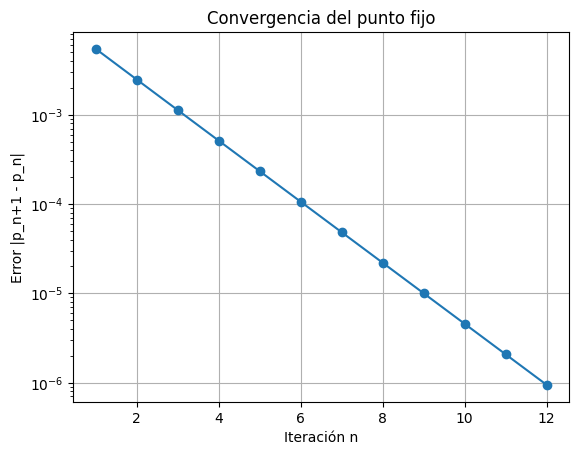

In [20]:
plt.semilogy(tabla['n'], tabla['error'], 'o-')
plt.grid(True)
plt.xlabel('Iteración n'); plt.ylabel('Error |p_n+1 - p_n|')
plt.title('Convergencia del punto fijo')
plt.show()

**Lectura de la gráfica:** los puntos forman una línea recta descendente, así que el método tiene **convergencia lineal**. Cada error es aproximadamente $0.455$ veces el anterior (por ejemplo, $2.06\times10^{-6}/\,4.54\times10^{-6}\approx0.455$), valor que coincide con $|g'(p)|=g(p)/2\approx0.455<1$. Esto explica por qué la convergencia es lenta comparada con otros métodos como Newton: ganar un dígito decimal cuesta unas tres iteraciones.

**Comentarios sobre la sintaxis:** `plt.semilogy` dibuja con el eje $y$ en escala logarítmica; `'o-'` indica puntos unidos por una línea; `tabla['n']` y `tabla['error']` seleccionan columnas del `DataFrame` por su nombre.



<div style="border:3px solid #1f4e79;background:#eaf2f8;padding:16px 20px;border-radius:10px;font-size:17px">
<b style="color:#1f4e79;font-size:19px">Resultado</b><br><br>
La raíz de $3x^2-e^x=0$ en el intervalo $[0.5,\,1]$, obtenida con $g(x)=\sqrt{e^x/3}$, $p_0=0.9$ y tolerancia $10^{-6}$, es<br><br>
<span style="font-size:24px;color:#c0392b"><b>$p\approx0.91000679\;\;(\approx0.91001)$</b></span><br><br>
alcanzada en <b>12 iteraciones</b>, con $f(p)\approx-2.3\times10^{-6}$.
</div>

### Conclusiones
- La ecuación $3x^2-e^x=0$ no tiene solución analítica; la gráfica permitió ubicar la raíz cercana a $0.91$.
- El despeje $g(x)=\sqrt{e^x/3}$ cumple el teorema de convergencia en $[0.5,1]$ con $k\approx0.476<1$, por lo que el método **converge** a un único punto fijo.
- La convergencia es **lineal**, con razón aproximada $0.455$; el número de iteraciones (12) es consistente con la cota teórica (13).
- Elegir bien $g$ es importante: este mismo despeje **no sirve** para la raíz cercana a $3.73$, porque ahí $|g'|\approx1.87>1$ y la iteración diverge.

### Observación: las otras raíces
La ecuación tiene dos raíces reales más, que requieren otro despeje con $|g'(p)|<1$:

| Raíz aproximada | Despeje | $g'(x)$ |
|:---:|:---:|:---:|
| $-0.459$ | $g_2(x)=-\sqrt{e^x/3}$ (rama negativa) | $g_2(x)/2$, con $\lvert g_2'\rvert\approx0.23$ |
| $3.733$ | $g_3(x)=\ln(3x^2)$ (de $e^x=3x^2$) | $2/x$, con $g_3'\approx0.54$ |